# Classificação Supervisionada com KMeans no Dataset Dry Bean (Balanceado)

Este notebook apresenta um pipeline didático e numerado para classificação supervisionada utilizando KMeans no dataset Dry Bean, com balanceamento das classes via oversampling. O objetivo é avaliar o impacto do balanceamento no desempenho do agrupamento multiclasse.

## 1. Importação das Bibliotecas

In [44]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, confusion_matrix, mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.utils import resample
import os
import seaborn as sns
os.makedirs('img', exist_ok=True)

## 2. Carregamento e Balanceamento dos Dados

O dataset Dry Bean é carregado e as classes minoritárias são balanceadas por oversampling, igualando a quantidade de exemplos de todas as classes. Isso evita que o modelo favoreça as classes majoritárias.

In [45]:
# Carregar o dataset Dry Bean
bean_df = pd.read_excel('data/DryBeanDataset/Dry_Bean_Dataset.xlsx')
bean_df = bean_df.dropna()

# Exibe distribuição original das classes
print('Distribuição original das classes:')
print(bean_df['Class'].value_counts())

# Balanceamento por oversampling (todas as classes terão o mesmo número de exemplos da classe majoritária)
max_count = bean_df['Class'].value_counts().max()
bean_df_balanced = pd.DataFrame()
for label in bean_df['Class'].unique():
    df_class = bean_df[bean_df['Class'] == label]
    df_upsampled = resample(df_class, replace=True, n_samples=max_count, random_state=42)
    bean_df_balanced = pd.concat([bean_df_balanced, df_upsampled])
bean_df_balanced = bean_df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

# Exibe distribuição após balanceamento
print('Distribuição após balanceamento:')
print(bean_df_balanced['Class'].value_counts())

Distribuição original das classes:
Class
DERMASON    3546
SIRA        2636
SEKER       2027
HOROZ       1928
CALI        1630
BARBUNYA    1322
BOMBAY       522
Name: count, dtype: int64
Distribuição após balanceamento:
Class
BARBUNYA    3546
CALI        3546
BOMBAY      3546
SIRA        3546
DERMASON    3546
SEKER       3546
HOROZ       3546
Name: count, dtype: int64


## 3. Pré-processamento dos Dados

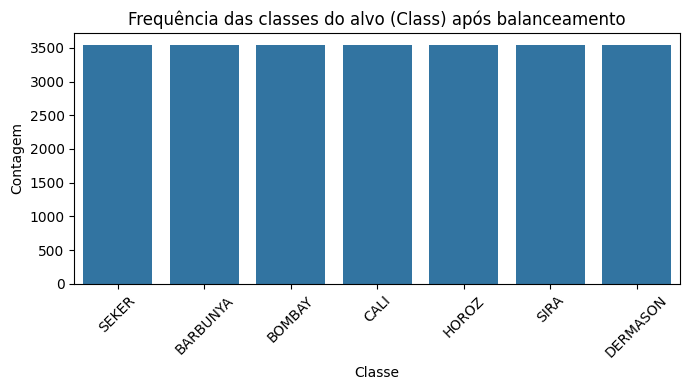

In [46]:
# Codificar variáveis categóricas
for col in bean_df_balanced.select_dtypes(include='object').columns:
    bean_df_balanced[col] = LabelEncoder().fit_transform(bean_df_balanced[col].astype(str))

# Separar features e alvo
X = bean_df_balanced.drop('Class', axis=1).values
y = bean_df_balanced['Class'].values  # Multiclasse

# Normalizar os dados
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Visualizar frequência das classes do alvo
plt.figure(figsize=(7,4))
class_names = bean_df['Class'].unique()
sns.countplot(x=bean_df_balanced['Class'])
plt.title('Frequência das classes do alvo (Class) após balanceamento')
plt.xlabel('Classe')
plt.ylabel('Contagem')
plt.xticks(ticks=range(len(class_names)), labels=class_names, rotation=45)
plt.tight_layout()
plt.show()

## 4. Divisão em Treino/Teste

In [47]:
# Divisão dos dados em treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)

## 5. Definição do Número de Clusters

In [48]:
n_clusters = 10  # Definido pelo método do cotovelo (número de classes)

## 6. Implementação do KMeans Supervisionado

In [49]:
class KMeansSupervisionado:
    def __init__(self, n_clusters, random_state=0):
        self.n_clusters = n_clusters
        self.random_state = random_state
        self.kmeans = KMeans(n_clusters=n_clusters, random_state=random_state)
        self.cluster_labels_ = None

    def fit(self, X, y):
        clusters = self.kmeans.fit_predict(X)
        self.cluster_labels_ = []
        for i in range(self.n_clusters):
            mask = (clusters == i)
            if np.any(mask):
                label = np.bincount(y[mask]).argmax()
            else:
                label = -1
            self.cluster_labels_.append(label)

    def predict(self, X):
        clusters = self.kmeans.predict(X)
        return np.array([self.cluster_labels_[c] for c in clusters])

    def evaluate(self, X, y_true):
        y_pred = self.predict(X)
        acc = accuracy_score(y_true, y_pred)
        cm = confusion_matrix(y_true, y_pred)
        return acc, cm

## 7. Treinamento e Avaliação Inicial

Acurácia: 0.8539
Matriz de Confusão:
[[ 778    0  191    3   15   12   64]
 [   0 1057    7    0    0    0    0]
 [   4    0 1020    0   19    0   21]
 [   1    0    3  731    1   32  296]
 [   0    0  114    0  929    0   21]
 [   9    0    0  104    0  926   25]
 [   3    0   13  109   18    3  918]]


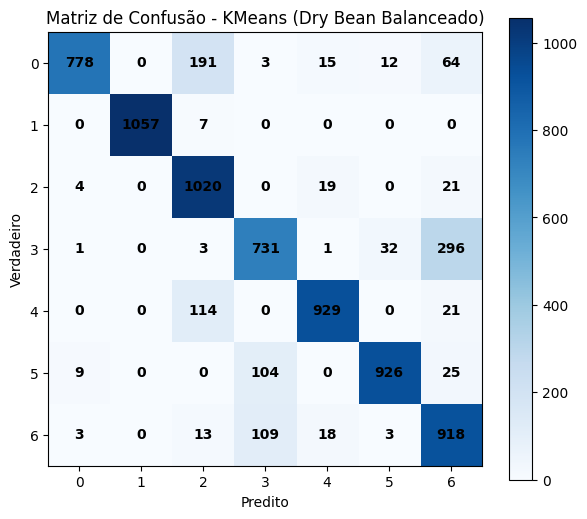

In [50]:
clf = KMeansSupervisionado(n_clusters=n_clusters, random_state=42)
clf.fit(X_train, y_train)
acc, cm = clf.evaluate(X_test, y_test)
print(f'Acurácia: {acc:.4f}')
print('Matriz de Confusão:')
print(cm)

plt.figure(figsize=(7,6))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Matriz de Confusão - KMeans (Dry Bean Balanceado)')
plt.colorbar()
plt.ylabel('Verdadeiro')
plt.xlabel('Predito')

# Adiciona os valores nas células
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm[i, j]), ha='center', va='center', color='black', fontsize=10, fontweight='bold')

plt.savefig('img/kmeans_drybean_balance_confusion_matrix.png')
plt.show()

## 8. Visualização dos Agrupamentos com PCA

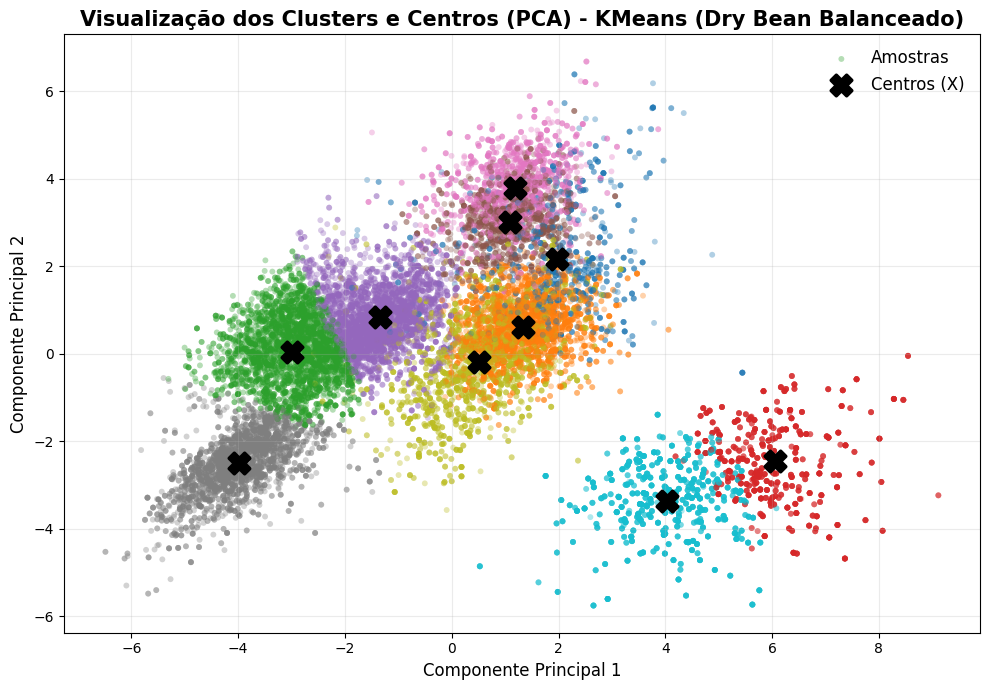

In [51]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)
cls = KMeans(n_clusters=n_clusters, random_state=42)
clusters = cls.fit_predict(X)
centros = cls.cluster_centers_
centros_pca = pca.transform(centros)

plt.figure(figsize=(10,7))
plt.scatter(
    X_pca[:,0], X_pca[:,1], 
    c=clusters, cmap='tab10', alpha=0.35, s=18, edgecolor='none', label='Amostras'
)
plt.scatter(
    centros_pca[:,0], centros_pca[:,1], 
    c='black', marker='X', s=220, linewidths=2.5, zorder=4, label='Centros (X)'
)
plt.title('Visualização dos Clusters e Centros (PCA) - KMeans (Dry Bean Balanceado)', fontsize=15, fontweight='bold')
plt.xlabel('Componente Principal 1', fontsize=12)
plt.ylabel('Componente Principal 2', fontsize=12)
plt.grid(alpha=0.25)
plt.legend(frameon=False, fontsize=12, loc='best')
plt.tight_layout()
plt.savefig('img/kmeans_drybean_balance_clusters_pca.png', dpi=150)
plt.show()

## 9. Repetição dos Experimentos e Análise Estatística

MSE médio: 1.3198
Desvio padrão do MSE: 0.1574
Acurácia média: 0.8433
Desvio padrão da acurácia: 0.0246


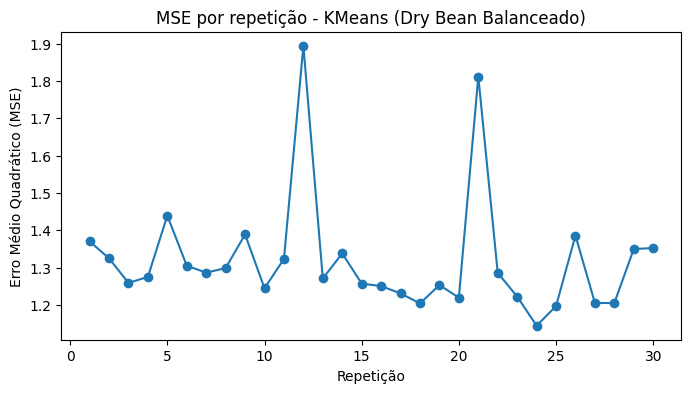

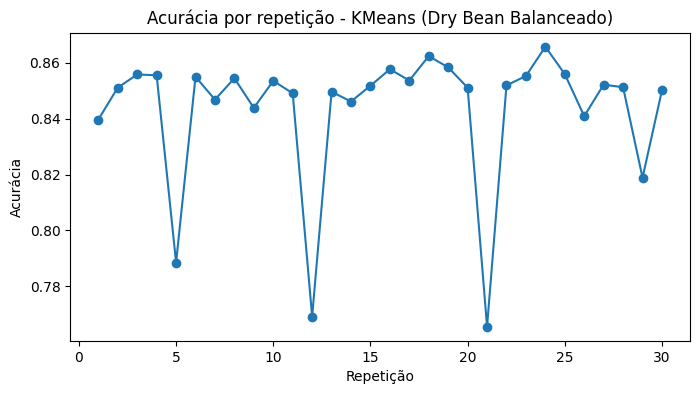

In [52]:
mse_list = []
acuracias = []
for seed in range(1, 31):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=seed, stratify=y)
    clf = KMeansSupervisionado(n_clusters=n_clusters, random_state=seed)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    mse_list.append(mse)
    acc, _ = clf.evaluate(X_test, y_test)
    acuracias.append(acc)

mse_array = np.array(mse_list)
acuracias = np.array(acuracias)
print(f'MSE médio: {mse_array.mean():.4f}')
print(f'Desvio padrão do MSE: {mse_array.std():.4f}')
print(f'Acurácia média: {acuracias.mean():.4f}')
print(f'Desvio padrão da acurácia: {acuracias.std():.4f}')

plt.figure(figsize=(8,4))
plt.plot(range(1, 31), mse_array, marker='o')
plt.xlabel('Repetição')
plt.ylabel('Erro Médio Quadrático (MSE)')
plt.title('MSE por repetição - KMeans (Dry Bean Balanceado)')
plt.savefig('img/kmeans_drybean_balance_mse_repetitions.png')
plt.show()

plt.figure(figsize=(8,4))
plt.plot(range(1,31), acuracias, marker='o')
plt.xlabel('Repetição')
plt.ylabel('Acurácia')
plt.title('Acurácia por repetição - KMeans (Dry Bean Balanceado)')
plt.savefig('img/kmeans_drybean_balance_accuracy_repetitions.png')
plt.show()

# Salvar MSE e acurácias para análise posterior
np.save('img/kmeans_drybean_balance_mse_repetitions.npy', mse_array)
np.savetxt('img/kmeans_drybean_balance_mse_repetitions.csv', mse_array, delimiter=',')
np.save('img/kmeans_drybean_balance_accuracies.npy', acuracias)
np.savetxt('img/kmeans_drybean_balance_accuracies.csv', acuracias, delimiter=',')

## 10. Análise dos Resultados e Métricas de Avaliação

Acurácia global: 0.8433
Precisão (macro): 0.8557
Recall (macro): 0.8433
F1-score (macro): 0.8449
Matriz de Confusão Média:
[[23162     0  6009   162   362   342  1883]
 [    2 31813    60     0    41     0     0]
 [  784     0 29545    27   884    84   591]
 [   69     0   117 23195    72  1462  7001]
 [    9     0  3985    41 27057     0   820]
 [  277     0    11  2582     4 28310   734]
 [   99     0   733  5033   474   244 25330]]


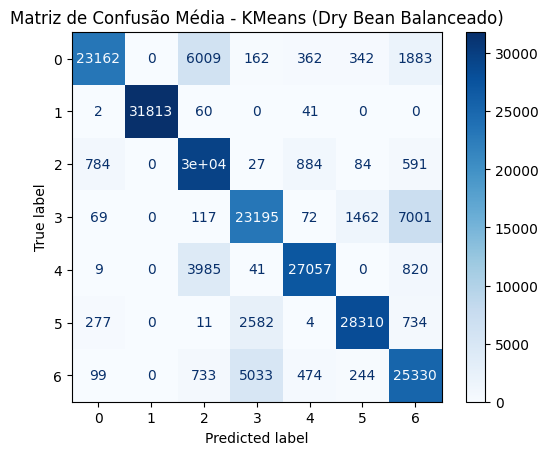

In [53]:
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

n_repeats = 30
y_true_all = []
y_pred_all = []
for seed in range(1, n_repeats+1):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=seed, stratify=y)
    clf = KMeansSupervisionado(n_clusters=n_clusters, random_state=seed)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    y_true_all.extend(y_test)
    y_pred_all.extend(y_pred)

acc = accuracy_score(y_true_all, y_pred_all)
prec = precision_score(y_true_all, y_pred_all, average='macro')
rec = recall_score(y_true_all, y_pred_all, average='macro')
f1 = f1_score(y_true_all, y_pred_all, average='macro')
cm = confusion_matrix(y_true_all, y_pred_all)

print(f"Acurácia global: {acc:.4f}")
print(f"Precisão (macro): {prec:.4f}")
print(f"Recall (macro): {rec:.4f}")
print(f"F1-score (macro): {f1:.4f}")
print("Matriz de Confusão Média:")
print(cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title('Matriz de Confusão Média - KMeans (Dry Bean Balanceado)')
plt.show()

## 11. Efeito do Número de Clusters na Matriz de Confusão

A matriz de confusão tem dimensões (n_classes, n_clusters). Se aumentarmos o número de clusters, a matriz terá mais colunas, mostrando como as classes verdadeiras são distribuídas entre os clusters extras. Isso pode revelar se há clusters "vazios" ou se o modelo está fragmentando classes em múltiplos grupos.

Matriz de confusão para n_clusters = 7: shape (7, 7)


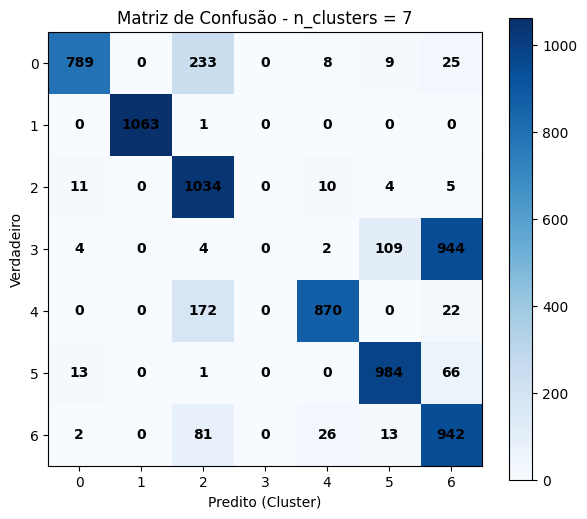

Matriz de confusão para n_clusters = 10: shape (7, 7)


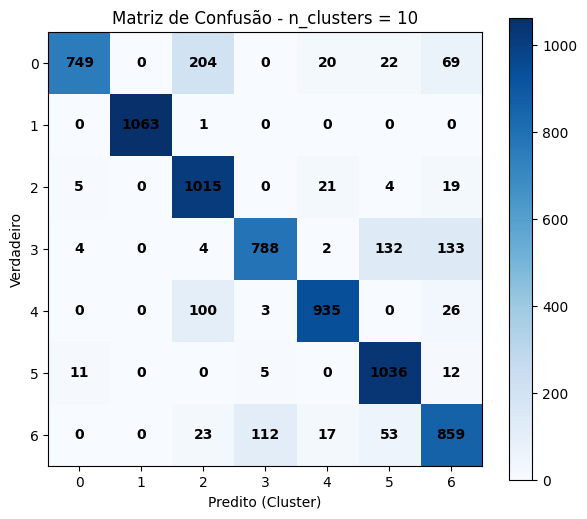

Matriz de confusão para n_clusters = 15: shape (7, 7)


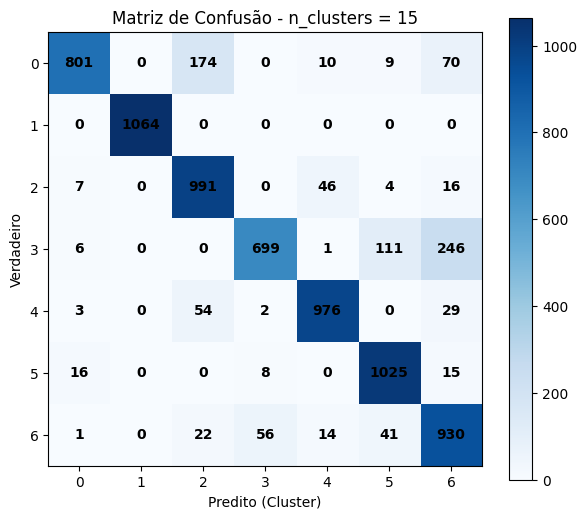

In [54]:
# Exemplo: Comparando matrizes de confusão para diferentes números de clusters
for n_clusters_test in [7, 10, 15]:
    clf = KMeansSupervisionado(n_clusters=n_clusters_test, random_state=42)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    print(f"Matriz de confusão para n_clusters = {n_clusters_test}: shape {cm.shape}")
    plt.figure(figsize=(7,6))
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title(f'Matriz de Confusão - n_clusters = {n_clusters_test}')
    plt.colorbar()
    plt.ylabel('Verdadeiro')
    plt.xlabel('Predito (Cluster)')
    # Adiciona os valores nas células
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, str(cm[i, j]), ha='center', va='center', color='black', fontsize=10, fontweight='bold')
    plt.show()